In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
print("Imported successfully!")

Imported successfully!


In [15]:
df = pd.read_csv('wine_quality.csv')

# Drop the target column to isolate features
X = df.drop('High_quality', axis=1)

# Isolate the target variable
y = df['High_quality']

print(f"Features shape (X): {X.shape}")
print(f"Target shape (y): {y.shape}")

Features shape (X): (4898, 11)
Target shape (y): (4898,)


In [26]:
# Cell 2.1: Descriptive Statistics
print("--- First 5 Rows of the Dataset ---")
display(df.head())

print("\n--- Summary Statistics ---")
display(df.describe())

--- First 5 Rows of the Dataset ---


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,High_quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,0
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,0
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,0
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,0
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,0



--- Summary Statistics ---


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,High_quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,0.216415
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.411842
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,0.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,0.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,0.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,0.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,1.000000


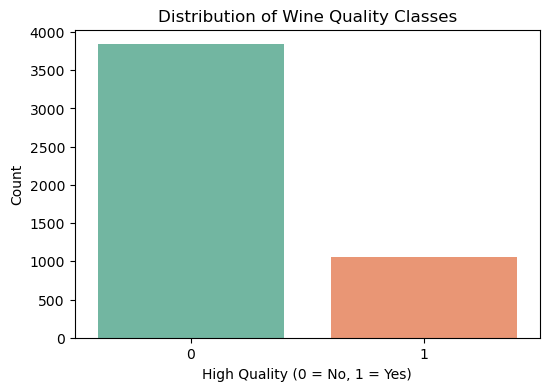

In [27]:
# Cell 2.2: Bar Chart - Distribution of Wine Quality Classes
plt.figure(figsize=(6, 4))
sns.countplot(x='High_quality', data=df, palette='Set2')
plt.title('Distribution of Wine Quality Classes')
plt.xlabel('High Quality (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

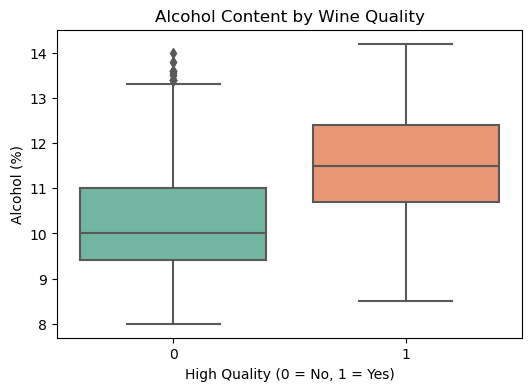

In [28]:
# Cell 2.3: Box Plot - Alcohol Content by Wine Quality
plt.figure(figsize=(6, 4))
sns.boxplot(x='High_quality', y='alcohol', data=df, palette='Set2')
plt.title('Alcohol Content by Wine Quality')
plt.xlabel('High Quality (0 = No, 1 = Yes)')
plt.ylabel('Alcohol (%)')
plt.show()

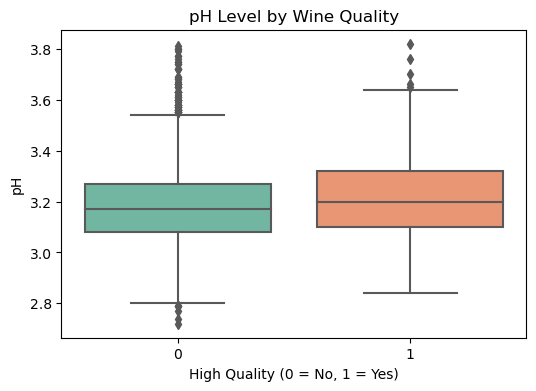

In [29]:
# Cell 2.4: Box Plot - pH Level by Wine Quality
plt.figure(figsize=(6, 4))
sns.boxplot(x='High_quality', y='pH', data=df, palette='Set2')
plt.title('pH Level by Wine Quality')
plt.xlabel('High Quality (0 = No, 1 = Yes)')
plt.ylabel('pH')
plt.show()

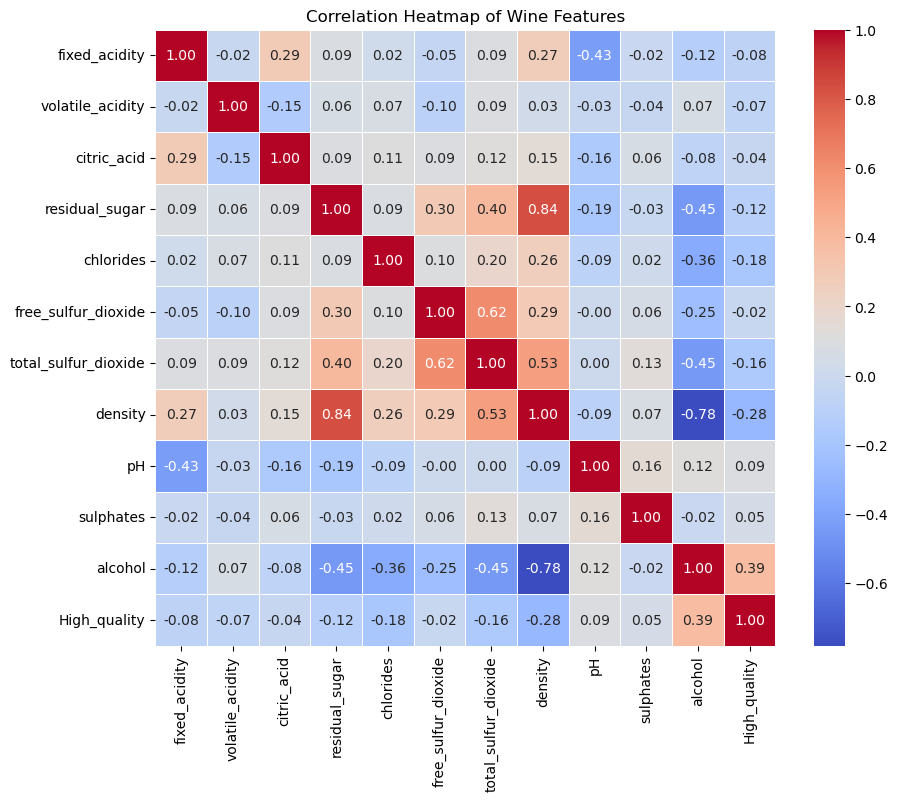

In [31]:
# Cell 2.5: Correlation Heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Wine Features')
plt.show() 

In [16]:
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both train and test sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data successfully split and scaled!")
print(f"Training set size: {X_train_scaled.shape[0]} samples")
print(f"Testing set size: {X_test_scaled.shape[0]} samples")

Data successfully split and scaled!
Training set size: 3918 samples
Testing set size: 980 samples


In [17]:
from sklearn.model_selection import GridSearchCV

print("Starting Grid Search for Random Forest. This might take a few seconds...")

# 1. Define the parameter grid to test
rf_param_grid = {
    'n_estimators': [50, 100, 150],      # Number of trees in the forest
    'max_depth': [None, 10, 20],         # Maximum depth of the trees
    'min_samples_split': [2, 5]          # Minimum samples required to split a node
}

# 2. Initialize the base model
rf_base = RandomForestClassifier(random_state=42, class_weight='balanced') 
# Note: 'balanced' helps handle the fact that we have fewer "High Quality" wines

# 3. Set up the Grid Search
rf_grid = GridSearchCV(estimator=rf_base, param_grid=rf_param_grid, 
                       cv=3, scoring='accuracy', n_jobs=-1)

# 4. Fit the model to our scaled training data
rf_grid.fit(X_train_scaled, y_train)

# 5. Extract the best model
best_rf_model = rf_grid.best_estimator_

print("\nGrid Search Complete!")
print("Best Random Forest Parameters found:")
print(rf_grid.best_params_)

Starting Grid Search for Random Forest. This might take a few seconds...

Grid Search Complete!
Best Random Forest Parameters found:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}


--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       768
           1       0.85      0.58      0.69       212

    accuracy                           0.89       980
   macro avg       0.87      0.78      0.81       980
weighted avg       0.88      0.89      0.88       980



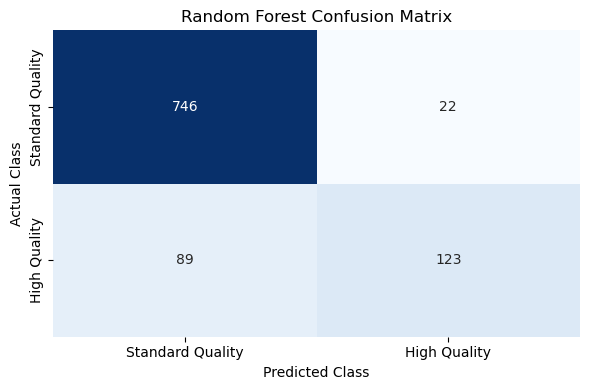

In [18]:
# 1. Predict on the test set
y_pred_rf = best_rf_model.predict(X_test_scaled)

# 2. Print the text report (Accuracy, Precision, Recall, F1-Score)
print("--- Random Forest Classification Report ---")
print(classification_report(y_test, y_pred_rf))

# 3. Create a visual Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Standard Quality', 'High Quality'],
            yticklabels=['Standard Quality', 'High Quality'])
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.show()

In [19]:
from sklearn.svm import SVC

print("Starting Grid Search for SVM. This might take a minute or two...")

# 1. Define the parameter grid to test
svm_param_grid = {
    'C': [0.1, 1, 10],                 # Regularization parameter
    'kernel': ['linear', 'rbf'],       # Type of mathematical transformation
    'gamma': ['scale', 'auto']         # Kernel coefficient for 'rbf'
}

# 2. Initialize the base model with balanced class weights
svm_base = SVC(random_state=42, class_weight='balanced')

# 3. Set up the Grid Search
svm_grid = GridSearchCV(estimator=svm_base, param_grid=svm_param_grid, 
                        cv=3, scoring='accuracy', n_jobs=-1)

# 4. Fit the model to our scaled training data
svm_grid.fit(X_train_scaled, y_train)

# 5. Extract the best model
best_svm_model = svm_grid.best_estimator_

print("\nGrid Search Complete!")
print("Best SVM Parameters found:")
print(svm_grid.best_params_)

Starting Grid Search for SVM. This might take a minute or two...

Grid Search Complete!
Best SVM Parameters found:
{'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}


--- Support Vector Machine (SVM) Classification Report ---
              precision    recall  f1-score   support

           0       0.95      0.75      0.84       768
           1       0.49      0.85      0.62       212

    accuracy                           0.77       980
   macro avg       0.72      0.80      0.73       980
weighted avg       0.85      0.77      0.79       980



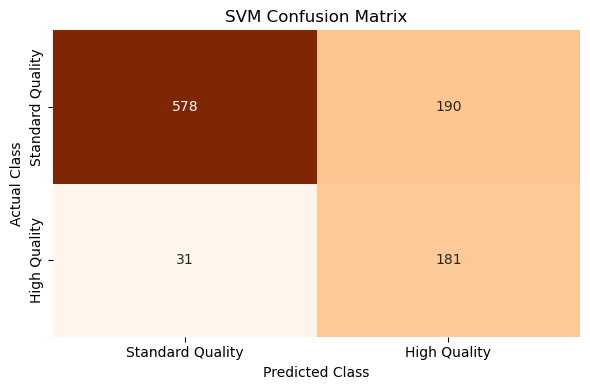

In [20]:
# 1. Predict on the test set
y_pred_svm = best_svm_model.predict(X_test_scaled)

# 2. Print the text report (Accuracy, Precision, Recall, F1-Score)
print("--- Support Vector Machine (SVM) Classification Report ---")
print(classification_report(y_test, y_pred_svm))

# 3. Create a visual Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Standard Quality', 'High Quality'],
            yticklabels=['Standard Quality', 'High Quality'])
plt.title('SVM Confusion Matrix')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.show()

In [21]:
# 1. We already have X (features only, no High_quality column) from earlier.
# 2. Re-initialize a scaler for the full dataset
scaler_full = StandardScaler()

# 3. Scale the entire feature set
X_scaled_full = scaler_full.fit_transform(X)

print("Full dataset successfully scaled for clustering!")
print(f"Dataset shape: {X_scaled_full.shape}")

Full dataset successfully scaled for clustering!
Dataset shape: (4898, 11)


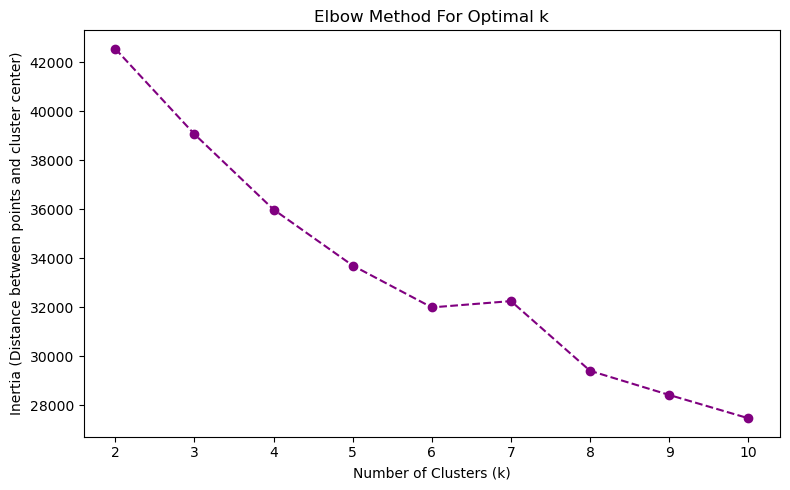

In [22]:
# k values from 2 to 10
inertia_values = []
k_range = range(2, 11)

for k in k_range:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans_test.fit(X_scaled_full)
    inertia_values.append(kmeans_test.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_values, marker='o', linestyle='--', color='purple')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Distance between points and cluster center)')
plt.xticks(k_range)
plt.tight_layout()
plt.show()

In [24]:
# 1. Fit the final K-Means model
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
cluster_labels = final_kmeans.fit_predict(X_scaled_full)

# 2. Add the cluster labels back to a copy of our original dataframe for profiling
df_clusters = X.copy()
df_clusters['Cluster'] = cluster_labels

# 3. Profile the clusters by calculating the mean of each feature per cluster
cluster_profiles = df_clusters.groupby('Cluster').mean()

print(f"--- Cluster Profiles (Mean values for k={optimal_k}) ---")
display(cluster_profiles.T) # Transposed for easier reading

--- Cluster Profiles (Mean values for k=3) ---


Cluster,0,1,2
fixed_acidity,7.426753,6.959545,6.222342
volatile_acidity,0.274006,0.282486,0.277363
citric_acid,0.349217,0.362952,0.288771
residual_sugar,3.931178,11.119700,3.375876
chlorides,0.041364,0.054730,0.039832
free_sulfur_dioxide,25.985705,46.258324,31.597111
total_sulfur_dioxide,114.956433,172.169256,122.047019
density,0.992551,0.997025,0.992040
pH,3.096215,3.155533,3.307634
sulphates,0.452342,0.497114,0.515661


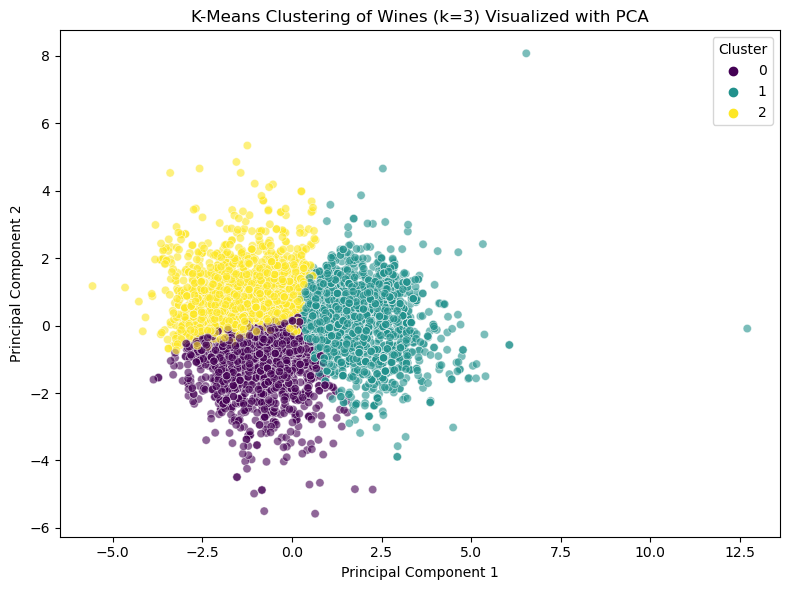

In [25]:
from sklearn.decomposition import PCA

# Reduce the 11 features to 2 dimensions for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_full)

# Create a DataFrame for plotting
df_pca = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
df_pca['Cluster'] = cluster_labels

# Plot the clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', 
                hue='Cluster', palette='viridis', data=df_pca, alpha=0.6)
plt.title(f'K-Means Clustering of Wines (k={optimal_k}) Visualized with PCA')
plt.tight_layout()
plt.show()